# A minimal plot example

### Load Packages
We need basic packages, intake (for catalogs) and healpix 
Make sure you have the hackathon environment installed. (This may be node specific. Please check with your local host.)

In [116]:
## Standard Stuff
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.pyplot as plt
import dask.array as da
import numcodecs
import cftime

## HEALPix Specific
import healpix as hp
import easygems.healpix as egh
import easygems.remap as egr

import intake     # For catalogs
import zarr       # Data Formatting

In [117]:
def worldmap(var, **kwargs):
    projection = ccrs.Robinson(central_longitude=-135.5808361)
    fig, ax = plt.subplots(
        figsize=(8, 4), subplot_kw={"projection": projection}, constrained_layout=True
    )
    ax.set_global()

    hpshow = egh.healpix_show(var, ax=ax, **kwargs)
    cbar = plt.colorbar(hpshow, ax=ax, orientation='vertical', 
                    pad=0.05, shrink=0.8)
    # fails when cartopy tries to download 
    # ax.add_feature(cf.COASTLINE, linewidth=0.8)
    # ax.add_feature(cf.BORDERS, linewidth=0.4)


### Load the catalog

In [118]:
catfn='/home/tmerlis/hackathon/xsh24_scream_main.yaml'
combo_cat = intake.open_catalog(catfn)

# right now, have coarse and native (don't have time-independent bcs)
print(list(combo_cat))

['xsh24_coarse', 'xsh24_native', 'xsh21_coarse', 'scream2D_hrly', 'scream_ne120', 'scream_lnd']


In [119]:
zoom_select = 6
print(combo_cat.xsh24_coarse(zoom=zoom_select))
ds = combo_cat.xsh24_coarse(zoom=zoom_select).to_dask()
ds = ds.drop_vars("cell")
ds = ds.pipe(egh.attach_coords)

# as of may5, no coarser than level 10 zooms for the native zarr store
# dsn = combo_cat.xsh24_native(zoom=10).to_dask()
# dsn = dsn.pipe(egh.attach_coords)

ds

sources:
  xsh24_coarse:
    args:
      chunks: {}
      consolidated: true
      urlpath: /scratch/cimes/GLOBALFV3/tmerlis/xsh24_coarse_hp6_may11.zarr
    description: ''
    driver: intake_xarray.xzarr.ZarrSource
    metadata:
      catalog_dir: /home/tmerlis/hackathon/



/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 249GB
Dimensions:  (time: 3560, cell: 49152, plev: 31, pfull: 79)
Coordinates:
  * pfull    (pfull) float32 316B 4.514 8.301 12.45 16.74 ... 989.5 994.3 998.3
  * plev     (plev) float32 124B 1.0 2.0 3.0 5.0 7.0 ... 925.0 950.0 975.0 1e+03
  * time     (time) object 28kB 2019-10-20 03:00:00 ... 2021-01-07 00:00:00
    crs      int64 8B 0
  * cell     (cell) int64 393kB 0 1 2 3 4 5 ... 49147 49148 49149 49150 49151
    lat      (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -1.194 -0.5968
    lon      (cell) float64 393kB 45.0 45.7 44.3 45.0 ... 315.7 314.3 315.0
Data variables: (12/38)
    clivi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clt      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clwvi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hflsd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hfssd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hur      (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    ...       ...
    uas      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    va       (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    vas      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    wa       (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    wap      (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    zg       (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>

In [120]:
ceres_cat = intake.open_catalog('/home/cs3554/CERES.yaml')
print(list(ceres_cat))
ceres = ceres_cat.CERES_EBAF_TOA_Ed421(zoom=zoom_select).to_dask()
ceres = ceres.pipe(egh.attach_coords)
ceres

['CERES_Cru23', 'CERES_EBAF_TOA_Ed421']


/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 650MB
Dimensions:                      (time: 300, cell: 49152)
Coordinates:
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 202...
    crs                          int64 8B 0
  * cell                         (cell) int64 393kB 0 1 2 ... 49149 49150 49151
    lat                          (cell) float64 393kB 0.5968 1.194 ... -0.5968
    lon                          (cell) float64 393kB 45.0 45.7 ... 314.3 315.0
Data variables:
    cldarea_total_daynight_mon   (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    cldpress_total_daynight_mon  (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    cldtau_total_day_mon         (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    cldtemp_total_daynight_mon   (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    solar_mon                    (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    toa_lw_all_mon               (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    toa_lw_clr_c_mon             (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    toa_net_all_mon              (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    toa_net_clr_c_mon            (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    toa_sw_all_mon               (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    toa_sw_clr_c_mon             (time, cell) float32 59MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    DOI:          10.5067/TERRA-AQUA-NOAA20/CERES/EBAF-TOA_L3B004.2.1
    comment:      Climatology from 07/2005 to 06/2015
    institution:  NASA/LaRC (Langley Research Center) Hampton, Va
    title:        CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Monthly...
    version:      Edition 4.2.1; Release Date November 25, 2024

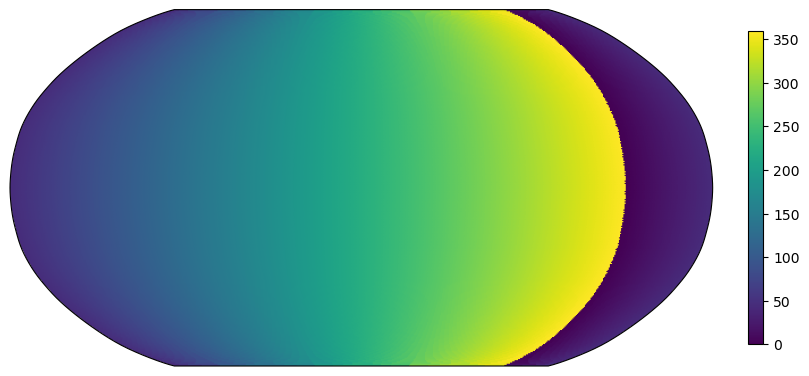

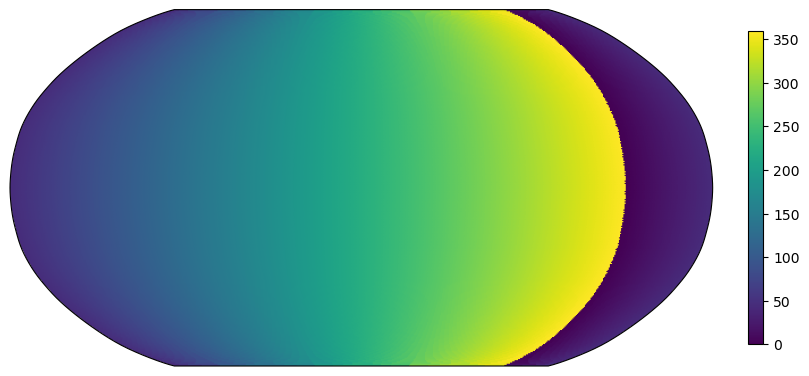

In [121]:
worldmap(ds.lon)
worldmap(ceres.lon)

CPU times: user 7.8 s, sys: 771 ms, total: 8.57 s
Wall time: 909 ms


Text(0.5, 1.0, 'rsut diff (xshield - CERES)')

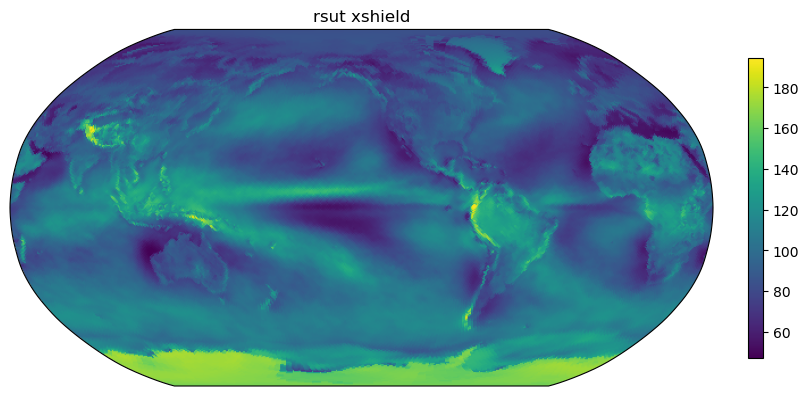

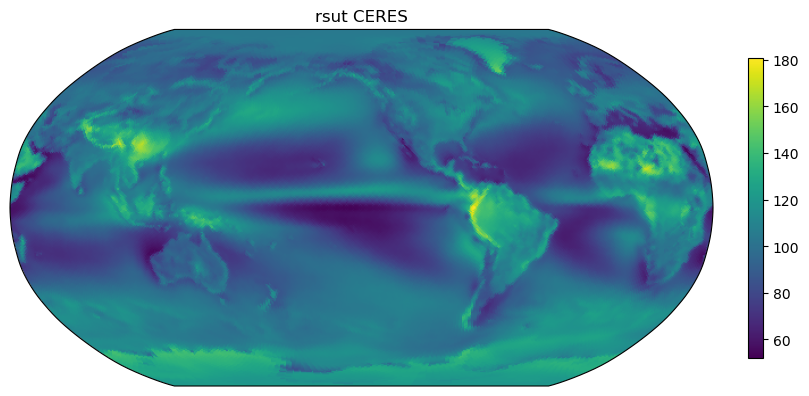

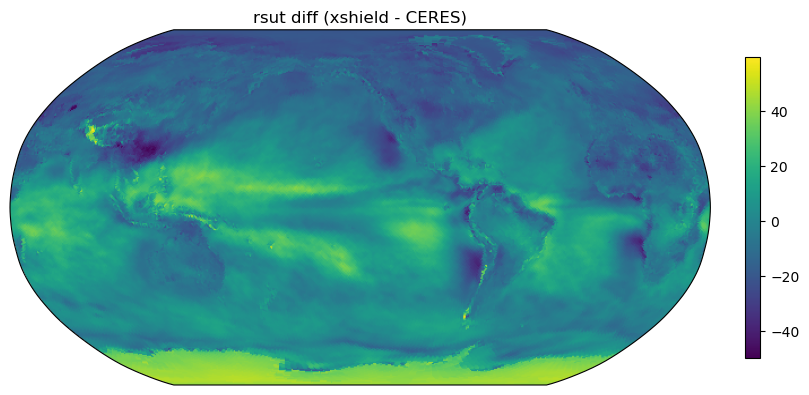

In [122]:
%%time
worldmap(ds.rsut.mean(dim='time'))
plt.title("rsut xshield")

worldmap(ceres.toa_sw_all_mon.mean(dim='time'))
plt.title("rsut CERES")

worldmap(ds.rsut.mean(dim='time') - ceres.toa_sw_all_mon.mean(dim='time'))
plt.title("rsut diff (xshield - CERES)")

CPU times: user 21.3 s, sys: 1.62 s, total: 22.9 s
Wall time: 1.87 s


Text(0.5, 1.0, 'net toa diff (xshield - CERES)')

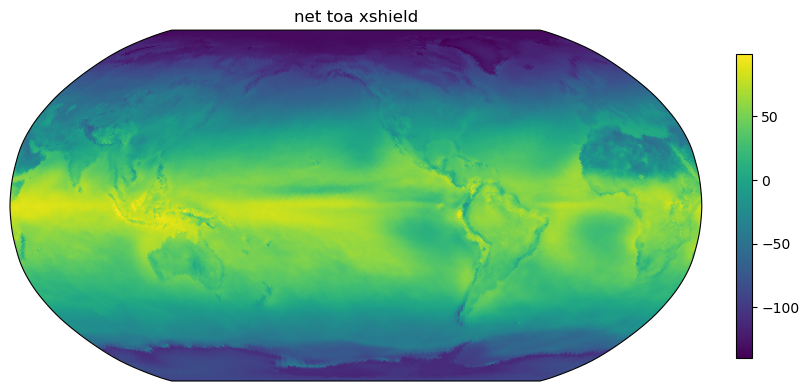

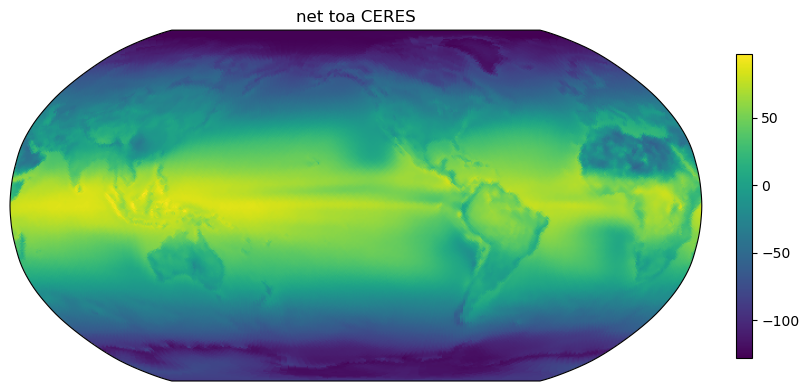

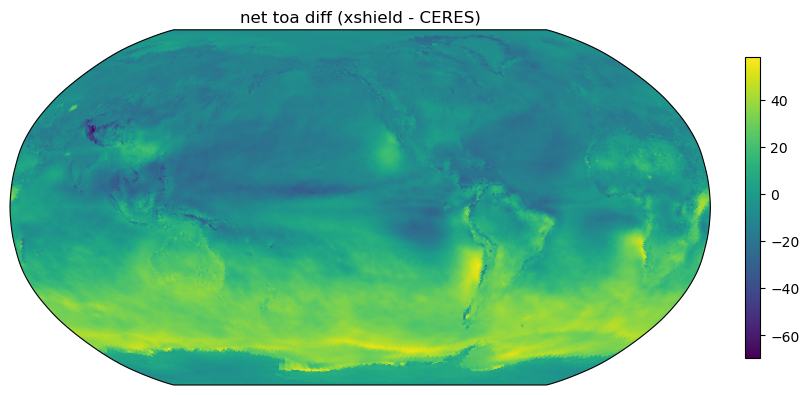

In [123]:
%%time
worldmap((ds.rsdt-ds.rsut-ds.rlut).mean(dim='time'))
plt.title("net toa xshield")

worldmap(ceres.toa_net_all_mon.mean(dim='time'))
plt.title("net toa CERES")

worldmap((ds.rsdt-ds.rsut-ds.rlut).mean(dim='time') - ceres.toa_net_all_mon.mean(dim='time'))
plt.title("net toa diff (xshield - CERES)")

CPU times: user 7.67 s, sys: 511 ms, total: 8.18 s
Wall time: 890 ms


Text(0.5, 1.0, 'rsutcs diff (xshield - CERES)')

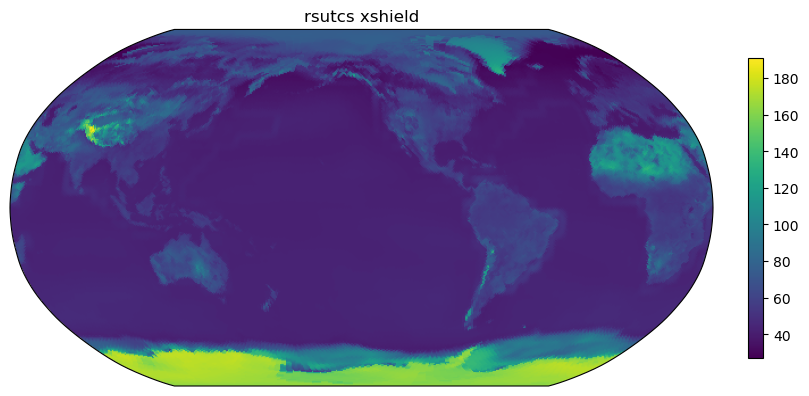

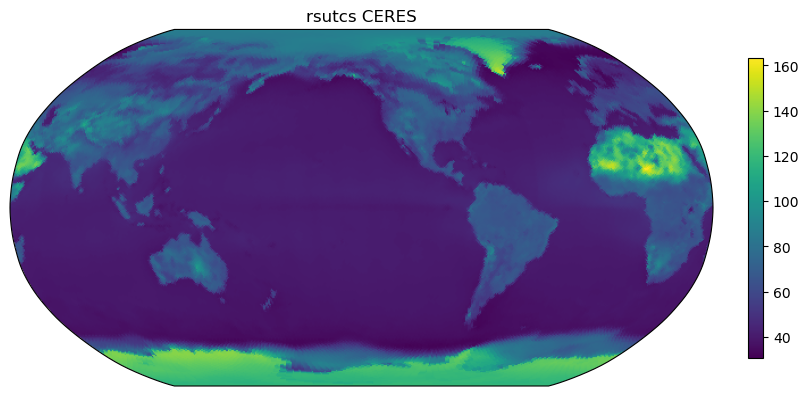

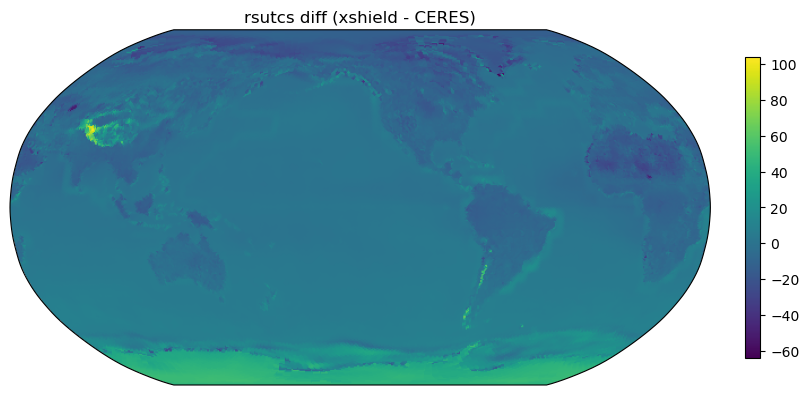

In [124]:
%%time
worldmap(ds.rsutcs.mean(dim='time'))
plt.title("rsutcs xshield")

worldmap(ceres.toa_sw_clr_c_mon.mean(dim='time'))
plt.title("rsutcs CERES")

worldmap(ds.rsutcs.mean(dim='time') - ceres.toa_sw_clr_c_mon.mean(dim='time'))
plt.title("rsutcs diff (xshield - CERES)")

In [125]:
nh = ds.where(ds.lat > 0)
sh = ds.where(ds.lat < 0)
# plt.plot(nh.time, nh.rsut)
# plt.show()

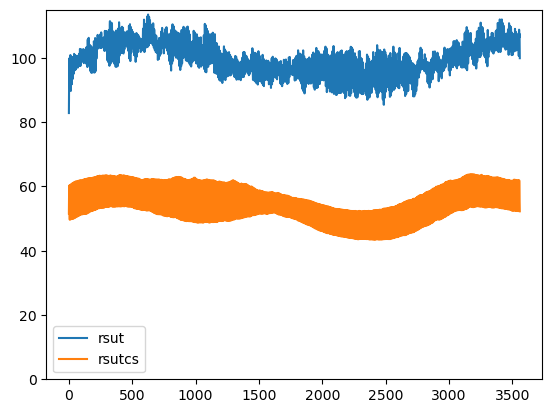

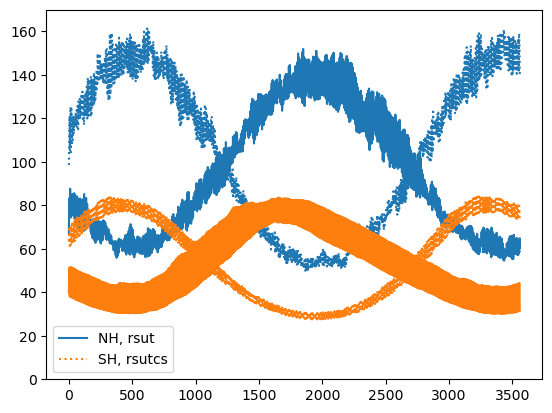

In [126]:
plt.plot(ds.rsut.mean(dim="cell"), label="rsut")
plt.plot(ds.rsutcs.mean(dim="cell"), label="rsutcs")
plt.ylim(0,115)
plt.legend()
plt.show()

plt.plot(nh.rsut.mean(dim="cell"), label="NH, rsut")
plt.plot(sh.rsut.mean(dim="cell"), ls=":", color="C0")
plt.plot(nh.rsutcs.mean(dim="cell"))
plt.plot(sh.rsutcs.mean(dim="cell"), ls=":", color="C1", label="SH, rsutcs")
plt.ylim(0,170)
plt.legend()
plt.show()

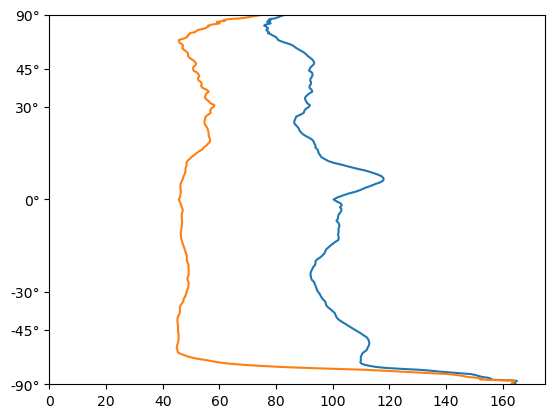

In [127]:
zm = ds.rsut.mean(dim='time').groupby("lat").mean()
zmcs = ds.rsutcs.mean(dim='time').groupby("lat").mean()
plt.plot(zm, np.sin(np.deg2rad(zm.lat)))
plt.plot(zmcs, np.sin(np.deg2rad(zmcs.lat)))
lats = [-90,-45,-30,0,30,45,90]
plt.yticks(np.sin(np.deg2rad(lats)), [str(x)+"°" for x in lats])
plt.ylim(-1,1)
plt.xlim(0,175)
plt.show()

-0.20778656
-12.706085


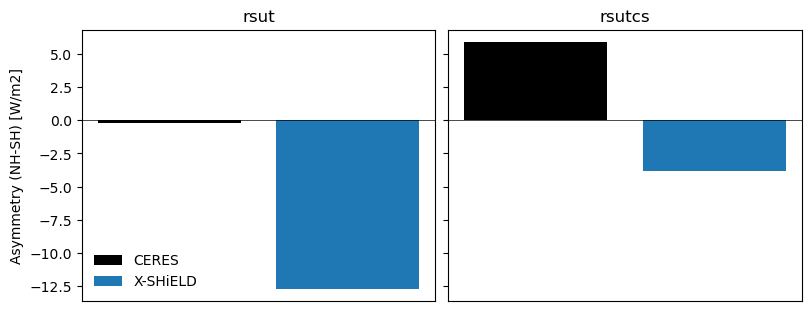

In [137]:
nhceres = ceres.where(ceres.lat > 0)
shceres = ceres.where(ceres.lat < 0)

asym = nh.rsut.mean(dim="cell").mean("time") - sh.rsut.mean(dim="cell").mean("time")
asymceres = nhceres.toa_sw_all_mon.mean(dim="cell").mean("time") - shceres.toa_sw_all_mon.mean(dim="cell").mean("time")

asym_cs = nh.rsutcs.mean(dim="cell").mean("time") - sh.rsutcs.mean(dim="cell").mean("time")
asymceres_cs = nhceres.toa_sw_clr_c_mon.mean(dim="cell").mean("time") - shceres.toa_sw_clr_c_mon.mean(dim="cell").mean("time")


print(asymceres.values)
print(asym.values)

fig,axes = plt.subplots(1,2,figsize=(8,3),sharey=True,constrained_layout=True)
ax = axes[0]
ax.set_title("rsut")
ax.bar(0, asymceres.values, color="k", label="CERES")
ax.bar(1, asym.values, label="X-SHiELD")
ax.legend(loc=3, frameon=False)
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks([])
ax.set_ylabel("Asymmetry (NH-SH) [W/m2]")

ax = axes[1]
ax.set_title("rsutcs")
ax.bar(0, asymceres_cs.values, color="k", label="CERES")
ax.bar(1, asym_cs.values, label="X-SHiELD")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks([])
plt.show()